In [2]:
import subprocess, sys 
  
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'openpyxl']: 
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q']) 
  
print('All libraries are installed')

All libraries are installed


In [3]:
import pandas as pd           
import numpy as np            
import matplotlib.pyplot as plt    
import seaborn as sns         
import plotly.express as px 
import plotly.graph_objects as go 
from plotly.subplots import make_subplots 
import warnings 
  
warnings.filterwarnings('ignore') 
sns.set_style('whitegrid') 
plt.rcParams['figure.figsize'] = (10, 5) 
  
print('Libraries imported successfully!')

Libraries imported successfully!


In [7]:
df = pd.read_excel(r'C:\Users\iyoha tega pc\Desktop\Analysis\Datasets\sales_records_dataset.xlsx') 

print(f'Dataset loaded! Shape: {df.shape[0]} rows × {df.shape[1]} columns')


Dataset loaded! Shape: 1000 rows × 14 columns


In [8]:
df.head() 

,Order_ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D
1,NaN,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C
3,ORD1004,Daniel Balogun,Female,East,Furniture,Bed,5.0,102967.0,514835.0,3286.0,87530.327068,NaN,Cash,Rep_B
4,ORD1005,Ibrahim Khan,Male,West,Electronics,Laptop,7.0,148887.0,1042209.0,741.0,67011.935599,2022-06-03,Transfer,Rep_D


In [9]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          955 non-null    object 
 1   Customer_Name     956 non-null    object 
 2   Gender            949 non-null    object 
 3   Region            941 non-null    object 
 4   Product_Category  944 non-null    object 
 5   Product_Name      961 non-null    object 
 6   Quantity          955 non-null    float64
 7   Unit_Price        949 non-null    float64
 8   Total_Sales       942 non-null    float64
 9   Discount          950 non-null    float64
 10  Profit            947 non-null    float64
 11  Order_Date        945 non-null    object 
 12  Payment_Method    944 non-null    object 
 13  Sales_Rep         955 non-null    object 
dtypes: float64(5), object(9)
memory usage: 109.5+ KB


In [10]:
df.describe().round(2) 

,Quantity,Unit_Price,Total_Sales,Discount,Profit
count,955.00,949.00,942.00,950.00,947.00
mean,5.53,75752.28,424735.26,2513.22,64645.40
std,2.85,42736.95,339359.57,1463.39,61028.39
min,1.00,2037.00,2118.00,0.00,171.57
25%,3.00,38059.00,133941.50,1271.00,17417.64
50%,6.00,76180.00,357334.50,2497.50,46940.54
75%,8.00,112145.00,621387.25,3796.25,93647.07
max,10.00,149555.00,1492040.00,4996.00,356652.16


In [11]:
missing = df.isnull().sum() 
missing_pct = (missing / len(df) * 100).round(2) 
  
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}) 
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', 
ascending=False) 
  
print('Columns with missing values:') 
print(missing_df.to_string())

Columns with missing values:
                  Missing Count  Missing %
Region                       59        5.9
Total_Sales                  58        5.8
Product_Category             56        5.6
Payment_Method               56        5.6
Order_Date                   55        5.5
Profit                       53        5.3
Gender                       51        5.1
Unit_Price                   51        5.1
Discount                     50        5.0
Order_ID                     45        4.5
Quantity                     45        4.5
Sales_Rep                    45        4.5
Customer_Name                44        4.4
Product_Name                 39        3.9


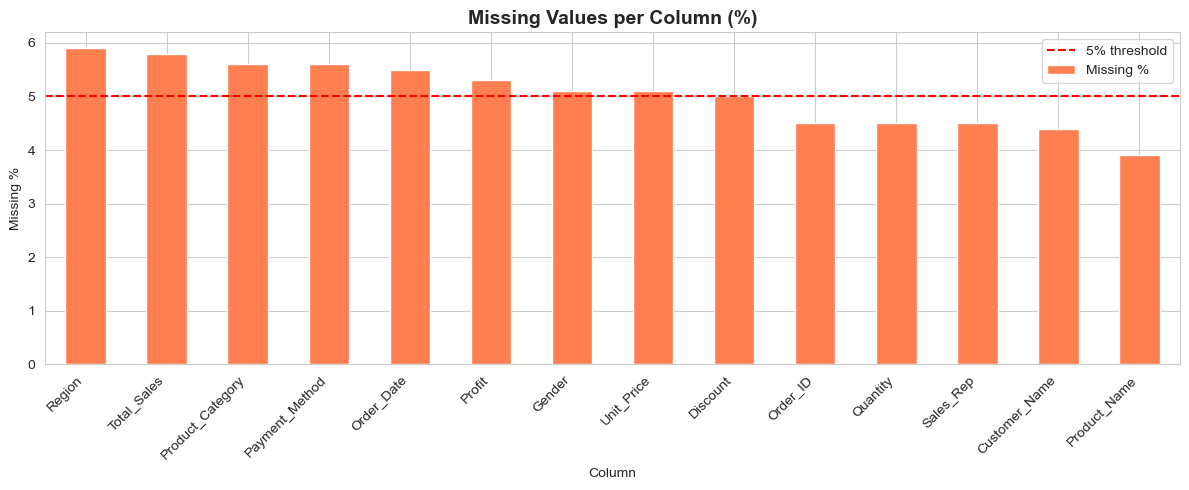

In [12]:
fig, ax = plt.subplots(figsize=(12, 5)) 
missing_df['Missing %'].plot(kind='bar', color='coral', ax=ax) 
ax.set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold') 
ax.set_xlabel('Column') 
ax.set_ylabel('Missing %') 
ax.axhline(5, color='red', linestyle='--', label='5% threshold') 
ax.legend() 
plt.xticks(rotation=45, ha='right') 
plt.tight_layout() 
plt.show()

In [13]:
cat_cols = ['Gender', 'Region', 'Product_Category', 'Payment_Method', 'Sales_Rep'] 
  
for col in cat_cols: 
    print(f'\n📌 {col}:') 
    print(df[col].value_counts(dropna=False).to_string()) 


📌 Gender:
Gender
Female    491
Male      458
NaN        51

📌 Region:
Region
South    258
East     239
West     232
North    212
NaN       59

📌 Product_Category:
Product_Category
Furniture      208
Electronics    204
Food           202
Clothing       184
Books          146
NaN             56

📌 Payment_Method:
Payment_Method
POS         253
Transfer    235
Online      234
Cash        222
NaN          56

📌 Sales_Rep:
Sales_Rep
Rep_D    251
Rep_A    249
Rep_C    230
Rep_B    225
NaN       45


In [15]:
dupes = df.duplicated().sum() 
print(f'Number of fully duplicate rows: {dupes}') 

Number of fully duplicate rows: 0


In [16]:
df_clean = df.copy() 
print(f'Working copy created. Shape: {df_clean.shape}')

Working copy created. Shape: (1000, 14)


In [19]:
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], errors='coerce') 
  
print('Order_Date dtype after fix:', df_clean['Order_Date'].dtype) 
print('Sample dates:', df_clean['Order_Date'].dropna().head(5).tolist())

Order_Date dtype after fix: datetime64[ns]
Sample dates: [Timestamp('2022-07-18 00:00:00'), Timestamp('2024-09-18 00:00:00'), Timestamp('2023-09-11 00:00:00'), Timestamp('2022-06-03 00:00:00'), Timestamp('2023-07-12 00:00:00')]


In [20]:
before = len(df_clean) 
df_clean.drop_duplicates(inplace=True) 
after = len(df_clean) 
  
print(f'Rows before: {before} | After: {after} | Removed: {before - after}')

Rows before: 1000 | After: 1000 | Removed: 0


In [25]:
df_clean['Quantity'] 
df_clean['Quantity'].fillna(df_clean['Quantity'].median()) 

0      3.0
1      2.0
2      9.0
3      5.0
4      7.0
      ... 
995    7.0
996    6.0
997    3.0
998    5.0
999    9.0
Name: Quantity, Length: 1000, dtype: float64

In [27]:
df_clean['Unit_Price'].fillna(df_clean['Unit_Price'].median()) 
df_clean['Total_Sales'] 
df_clean['Total_Sales'].fillna(df_clean['Total_Sales'].median()) 
df_clean['Profit']      = df_clean['Profit'].fillna(df_clean['Profit'].median()) 
df_clean['Discount']    = df_clean['Discount'].fillna(0) 
  
print('Numeric columns — remaining missing values:') 
print(df_clean[['Quantity','Unit_Price','Total_Sales','Profit','Discount']].isnull(
).sum()) 

Numeric columns — remaining missing values:
Quantity       45
Unit_Price     51
Total_Sales    58
Profit          0
Discount        0
dtype: int64


In [28]:
for col in ['Gender', 'Region', 'Product_Category', 'Payment_Method']: 
    mode_val = df_clean[col].mode()[0] 
    df_clean[col].fillna(mode_val, inplace=True) 
  
for col in ['Sales_Rep', 'Customer_Name', 'Order_ID', 'Product_Name']: 
    df_clean[col].fillna('Unknown', inplace=True) 
  
df_clean.dropna(subset=['Order_Date'], inplace=True) 
  
print('Remaining missing values after cleaning:') 
print(df_clean.isnull().sum()) 

Remaining missing values after cleaning:
Order_ID             0
Customer_Name        0
Gender               0
Region               0
Product_Category     0
Product_Name         0
Quantity            43
Unit_Price          47
Total_Sales         52
Discount             0
Profit               0
Order_Date           0
Payment_Method       0
Sales_Rep            0
dtype: int64


In [30]:
df_clean['Year']          = df_clean['Order_Date'].dt.year 
df_clean['Month']         = df_clean['Order_Date'].dt.month 
df_clean['Month_Name']    = df_clean['Order_Date'].dt.strftime('%b') 
df_clean['Quarter']       = df_clean['Order_Date'].dt.to_period('Q').astype(str) 
df_clean['Profit_Margin'] = (df_clean['Profit'] / df_clean['Total_Sales'] * 
100).round(2) 
  
print('New columns added:', 
['Year','Month','Month_Name','Quarter','Profit_Margin']) 
df_clean[['Order_Date','Year','Month','Month_Name','Quarter','Profit_Margin']].head


New columns added: ['Year', 'Month', 'Month_Name', 'Quarter', 'Profit_Margin']


<bound method NDFrame.head of     Order_Date  Year  Month Month_Name Quarter  Profit_Margin
0   2022-07-18  2022      7        Jul  2022Q3          18.19
1   2024-09-18  2024      9        Sep  2024Q3          12.94
2   2023-09-11  2023      9        Sep  2023Q3           5.87
4   2022-06-03  2022      6        Jun  2022Q2           6.43
5   2023-07-12  2023      7        Jul  2023Q3          22.40
..         ...   ...    ...        ...     ...            ...
995 2024-12-18  2024     12        Dec  2024Q4            NaN
996 2023-08-30  2023      8        Aug  2023Q3           8.50
997 2024-12-21  2024     12        Dec  2024Q4          12.95
998 2023-05-03  2023      5        May  2023Q2           8.28
999 2023-07-14  2023      7        Jul  2023Q3          23.62

[945 rows x 6 columns]>

In [31]:
print(f'Clean dataset shape: {df_clean.shape}') 
print(f'Rows removed during cleaning: {len(df) - len(df_clean)}') 
df_clean.head(3) 


Clean dataset shape: (945, 19)
Rows removed during cleaning: 55


,Order_ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep,Year,Month,Month_Name,Quarter,Profit_Margin
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D,2022,7,Jul,2022Q3,18.19
1,Unknown,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A,2024,9,Sep,2024Q3,12.94
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C,2023,9,Sep,2023Q3,5.87


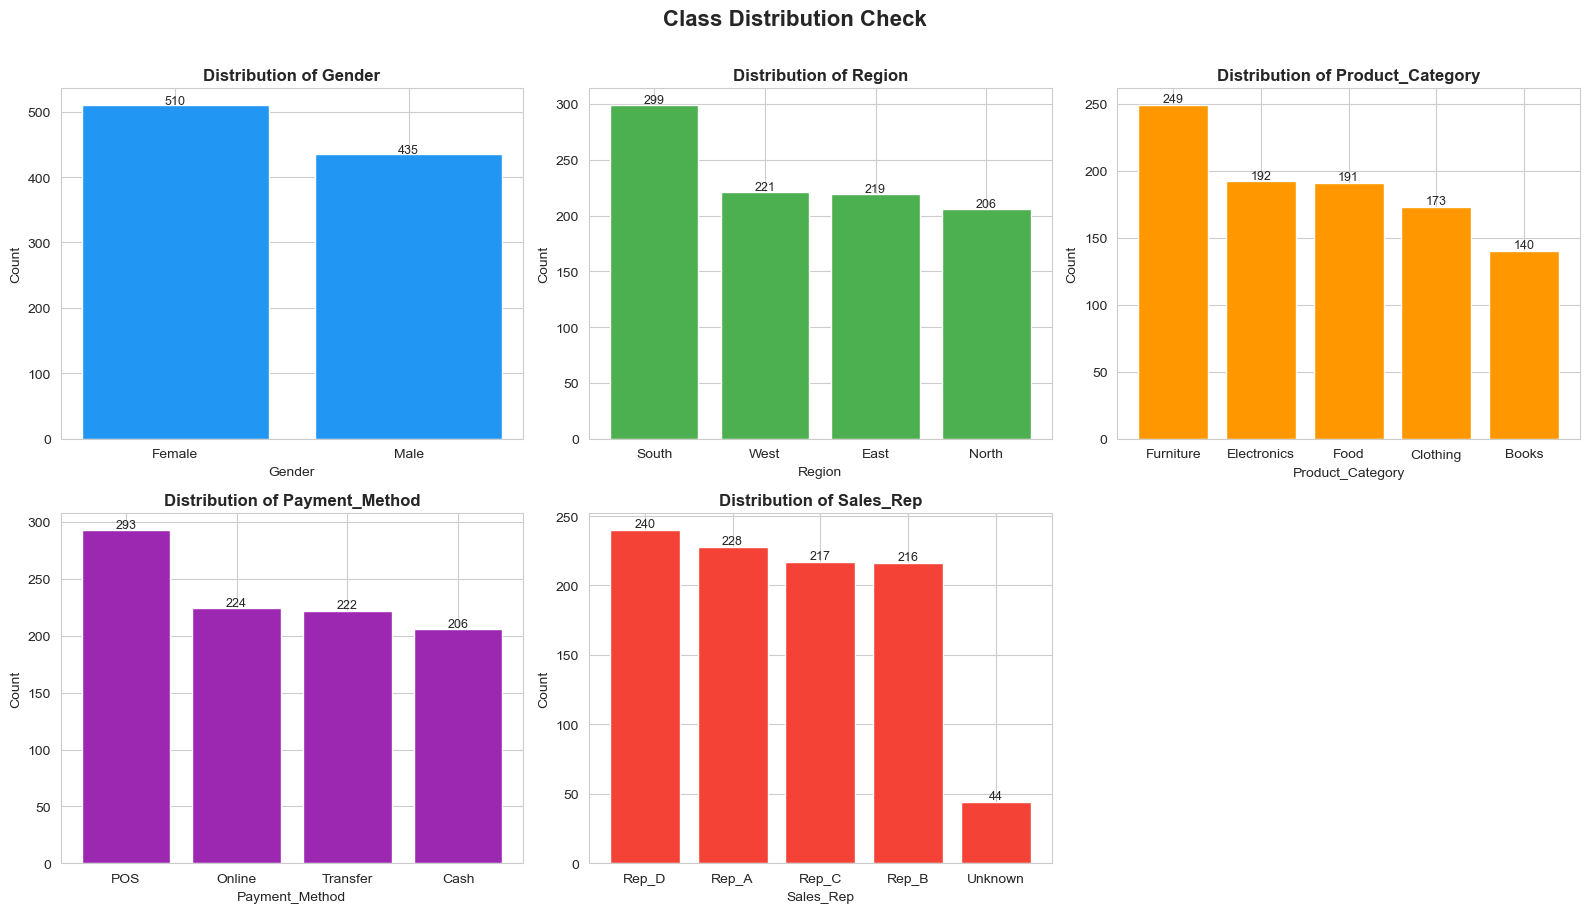

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9)) 
axes = axes.flatten() 
  
cat_cols = ['Gender', 'Region', 'Product_Category', 'Payment_Method', 'Sales_Rep'] 
colors   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'] 
  
for i, col in enumerate(cat_cols): 
    counts = df_clean[col].value_counts() 
    axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='white') 
    axes[i].set_title(f'Distribution of {col}', fontweight='bold') 
    axes[i].set_xlabel(col) 
    axes[i].set_ylabel('Count') 
    for j, v in enumerate(counts.values): 
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=9) 
  
axes[5].set_visible(False) 
plt.suptitle('Class Distribution Check', fontsize=16, fontweight='bold', y=1.01) 
plt.tight_layout() 
plt.show()

In [33]:
print('Imbalance Ratios (max / min count per category)\n') 
for col in cat_cols: 
    counts = df_clean[col].value_counts() 
    ratio  = counts.max() / counts.min() 
    status = 'Balanced' if ratio <= 2.0 else '⚠️ Imbalanced' 
    print(f'{col:<20} Ratio: {ratio:.2f}  {status}') 

Imbalance Ratios (max / min count per category)

Gender               Ratio: 1.17  Balanced
Region               Ratio: 1.45  Balanced
Product_Category     Ratio: 1.78  Balanced
Payment_Method       Ratio: 1.42  Balanced
Sales_Rep            Ratio: 5.45  ⚠️ Imbalanced


In [37]:
APPLY_BALANCING = False   # Change to True to activate 
BALANCE_COLUMN  = 'Product_Category' 
  
if APPLY_BALANCING: 
    min_count   = df_clean[BALANCE_COLUMN].value_counts().min() 
    df_balanced = ( 
        df_clean.groupby(BALANCE_COLUMN) 
                .apply(lambda x: x.sample(min_count, random_state=42)) 
                .reset_index(drop=True) 
    ) 
    print(f'Balanced shape: {df_balanced.shape}') 
    print(df_balanced[BALANCE_COLUMN].value_counts()) 
else: 
    df_balanced = df_clean.copy() 
    print('Using the full cleaned dataset.') 
    print(f'Shape: {df_balanced.shape}') 

Using the full cleaned dataset.
Shape: (945, 19)


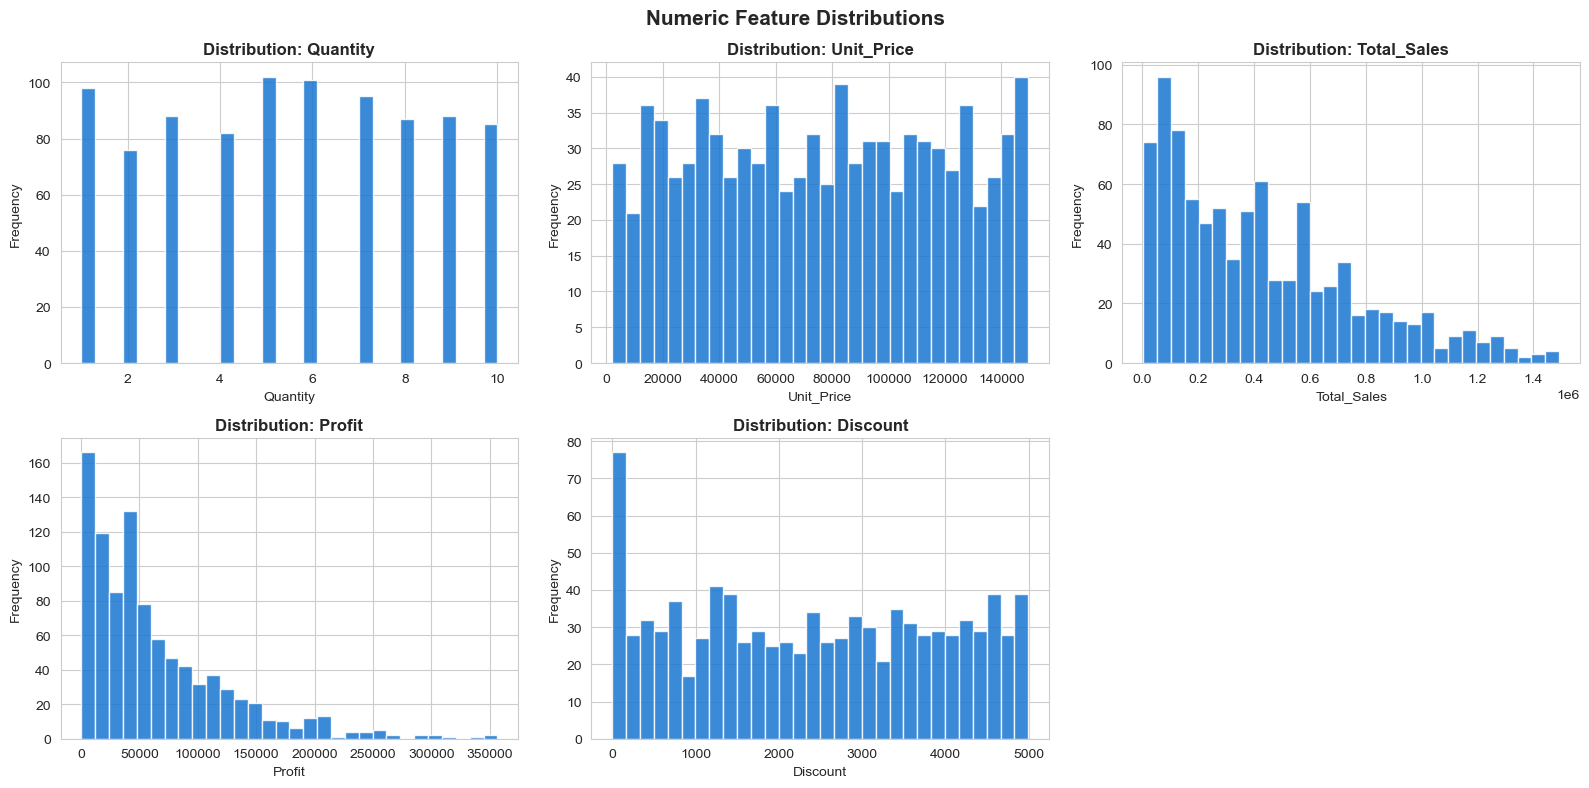

In [38]:
num_cols = ['Quantity', 'Unit_Price', 'Total_Sales', 'Profit', 'Discount'] 
  
fig, axes = plt.subplots(2, 3, figsize=(16, 8)) 
axes = axes.flatten() 
  
for i, col in enumerate(num_cols): 
    axes[i].hist(df_balanced[col], bins=30, color='#1976D2', 
                 edgecolor='white', alpha=0.85) 
    axes[i].set_title(f'Distribution: {col}', fontweight='bold') 
    axes[i].set_xlabel(col) 
    axes[i].set_ylabel('Frequency') 
  
axes[5].set_visible(False) 
plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold') 
plt.tight_layout() 
plt.show()

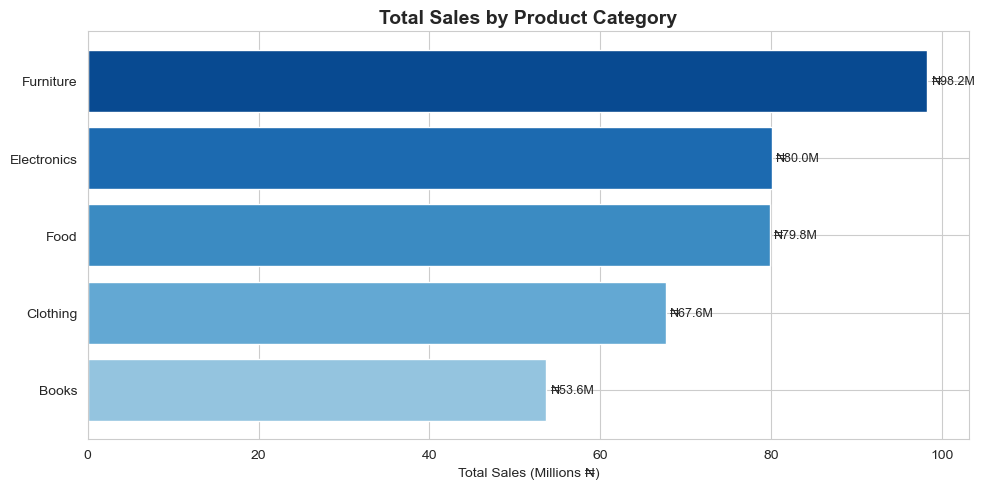

In [41]:
cat_sales = df_balanced.groupby('Product_Category')['Total_Sales'].sum()  .sort_values(ascending=True) 
  
fig, ax = plt.subplots(figsize=(10, 5)) 
colors  = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_sales))) 
bars    = ax.barh(cat_sales.index, cat_sales.values / 1e6, color=colors, 
edgecolor='white') 
  
for bar, val in zip(bars, cat_sales.values): 
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'₦{val/1e6:.1f}M', va='center', fontsize=9) 
  
ax.set_title('Total Sales by Product Category', fontsize=14, fontweight='bold') 
ax.set_xlabel('Total Sales (Millions ₦)') 
plt.tight_layout() 
plt.show()

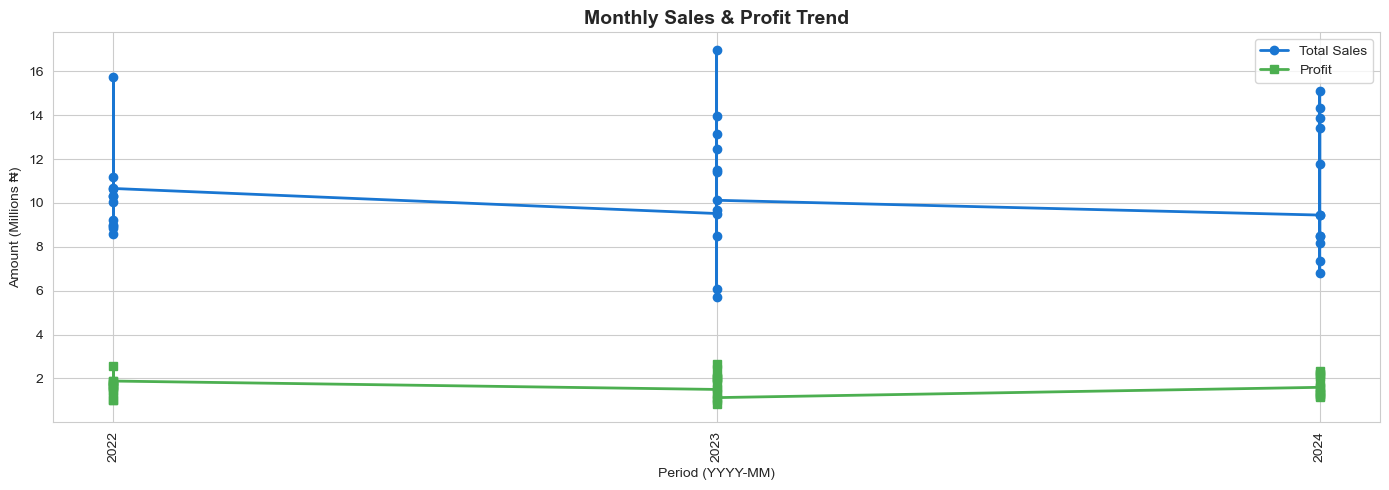

In [51]:
monthly = df_balanced.groupby(['Year','Month'])[['Total_Sales','Profit']] .sum().reset_index().sort_values(['Year','Month']) 

monthly['Period'] = monthly['Year'].astype(str) 
monthly['Month'].astype(str).str.zfill(2) 
  
fig, ax = plt.subplots(figsize=(14, 5)) 
ax.plot(monthly['Period'], monthly['Total_Sales']/1e6, 
        marker='o', color='#1976D2', label='Total Sales', linewidth=2) 
ax.plot(monthly['Period'], monthly['Profit']/1e6, 
        marker='s', color='#4CAF50', label='Profit', linewidth=2) 
ax.set_title('Monthly Sales & Profit Trend', fontsize=14, fontweight='bold') 
ax.set_xlabel('Period (YYYY-MM)') 
ax.set_ylabel('Amount (Millions ₦)') 
ax.legend() 
plt.xticks(rotation=90) 
plt.tight_layout() 
plt.show() 

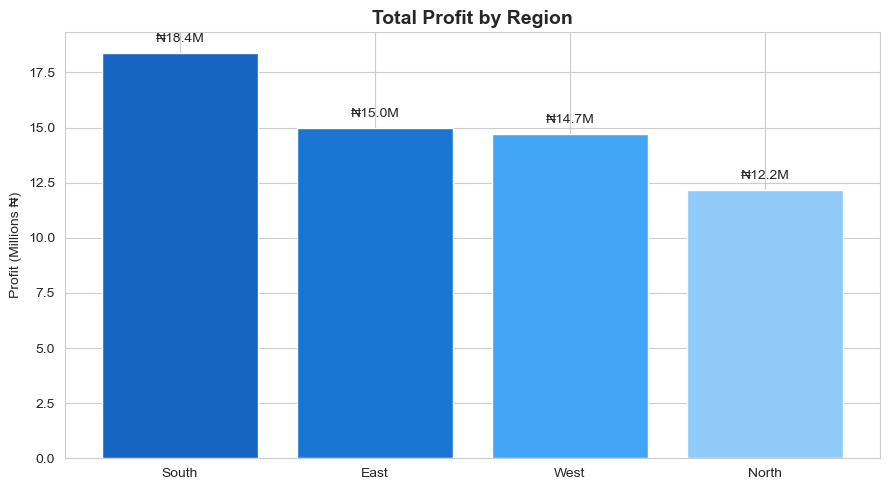

In [53]:
region_profit = df_balanced.groupby('Region')['Profit'].sum().sort_values(ascending=False) 
  
fig, ax = plt.subplots(figsize=(9, 5)) 
palette = ['#1565C0','#1976D2','#42A5F5','#90CAF9'] 
bars    = ax.bar(region_profit.index, region_profit.values/1e6, color=palette, 
edgecolor='white') 
  
for bar, val in zip(bars, region_profit.values): 
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'₦{val/1e6:.1f}M', ha='center', fontsize=10) 
  
ax.set_title('Total Profit by Region', fontsize=14, fontweight='bold') 
ax.set_ylabel('Profit (Millions ₦)') 
plt.tight_layout() 
plt.show()

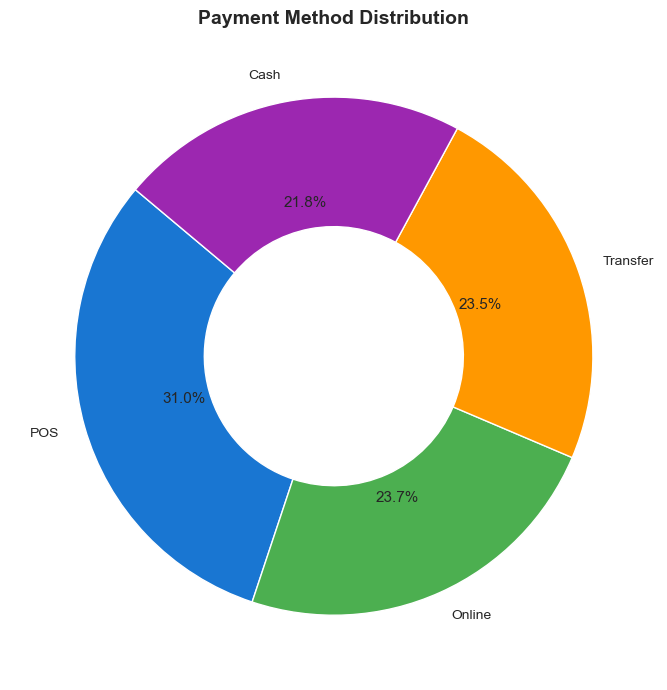

In [54]:
pay_counts = df_balanced['Payment_Method'].value_counts() 
fig, ax = plt.subplots(figsize=(7, 7)) 
wedges, texts, autotexts = ax.pie( 
    pay_counts.values, 
    labels=pay_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    wedgeprops={'width': 0.5}, 
    colors=['#1976D2','#4CAF50','#FF9800','#9C27B0'] 
) 
for t in autotexts: 
    t.set_fontsize(11) 
ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold') 
plt.tight_layout() 
plt.show() 

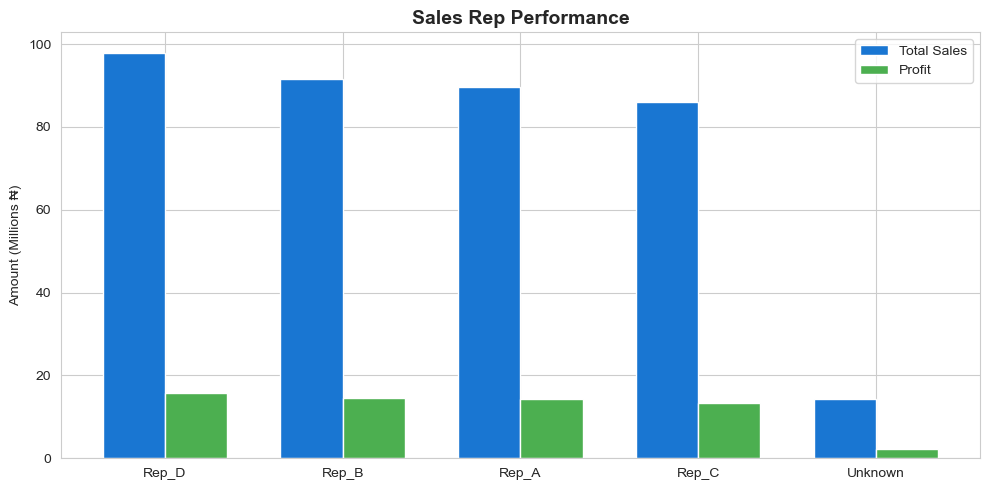

In [55]:
rep_perf = ( 
    df_balanced.groupby('Sales_Rep')[['Total_Sales','Profit']] 
               .sum().sort_values('Total_Sales', ascending=False) 
) 
  
fig, ax = plt.subplots(figsize=(10, 5)) 
x, w = np.arange(len(rep_perf)), 0.35 
  
ax.bar(x - w/2, rep_perf['Total_Sales']/1e6, width=w, label='Total Sales', 
color='#1976D2') 
ax.bar(x + w/2, rep_perf['Profit']/1e6,      width=w, label='Profit',      
color='#4CAF50') 
ax.set_xticks(x) 
ax.set_xticklabels(rep_perf.index) 
ax.set_title('Sales Rep Performance', fontsize=14, fontweight='bold') 
ax.set_ylabel('Amount (Millions ₦)') 
ax.legend() 
plt.tight_layout() 
plt.show()

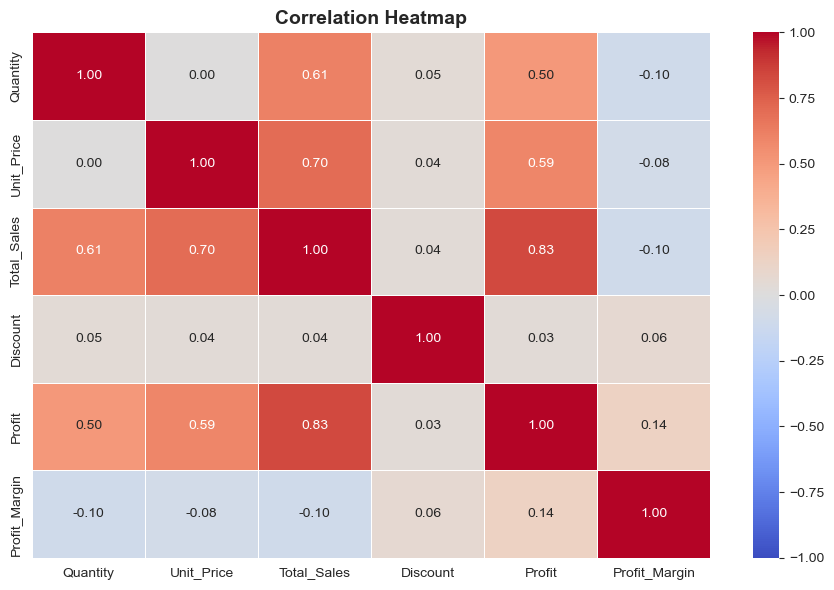

In [56]:
corr = df_balanced[['Quantity','Unit_Price','Total_Sales', 
                     'Discount','Profit','Profit_Margin']].corr() 
  
fig, ax = plt.subplots(figsize=(9, 6)) 
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, ax=ax, vmin=-1, vmax=1) 
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold') 
plt.tight_layout() 
plt.show() 

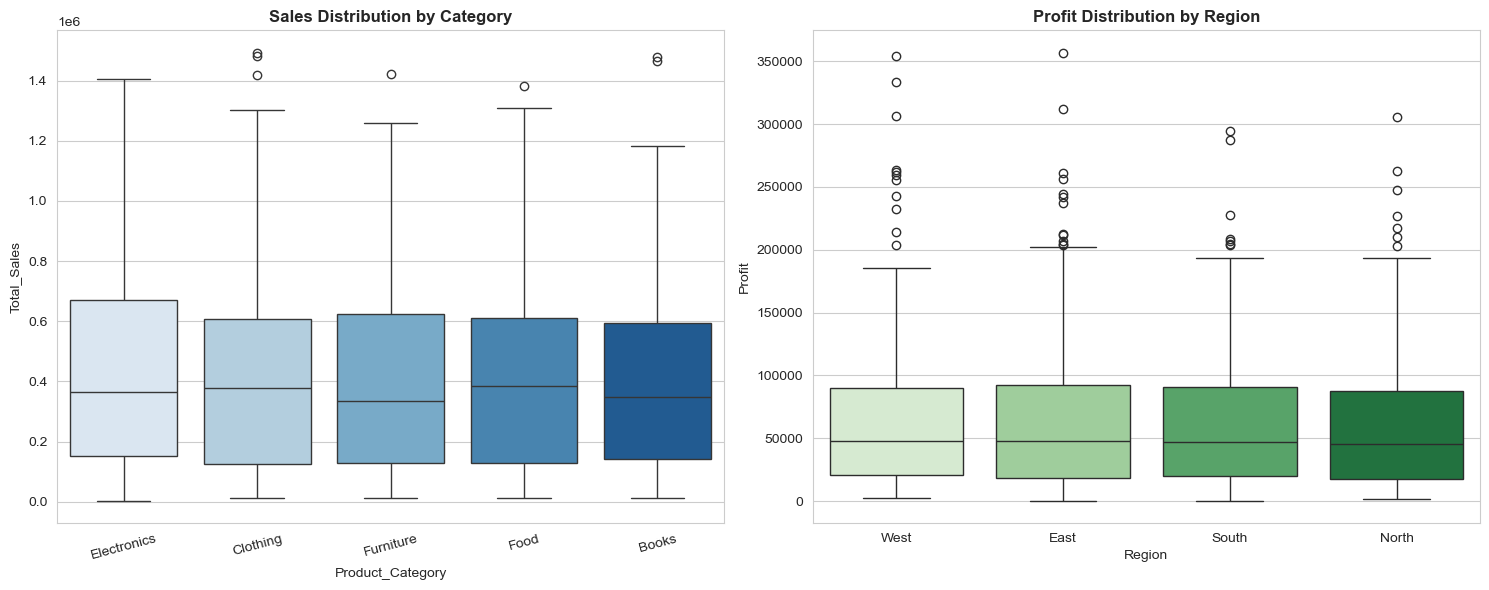

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) 
  
sns.boxplot(data=df_balanced, x='Product_Category', y='Total_Sales', 
            palette='Blues', ax=axes[0]) 
axes[0].set_title('Sales Distribution by Category', fontweight='bold') 
axes[0].tick_params(axis='x', rotation=15) 
  
sns.boxplot(data=df_balanced, x='Region', y='Profit', 
            palette='Greens', ax=axes[1]) 
axes[1].set_title('Profit Distribution by Region', fontweight='bold') 
  
plt.tight_layout() 
plt.show() 

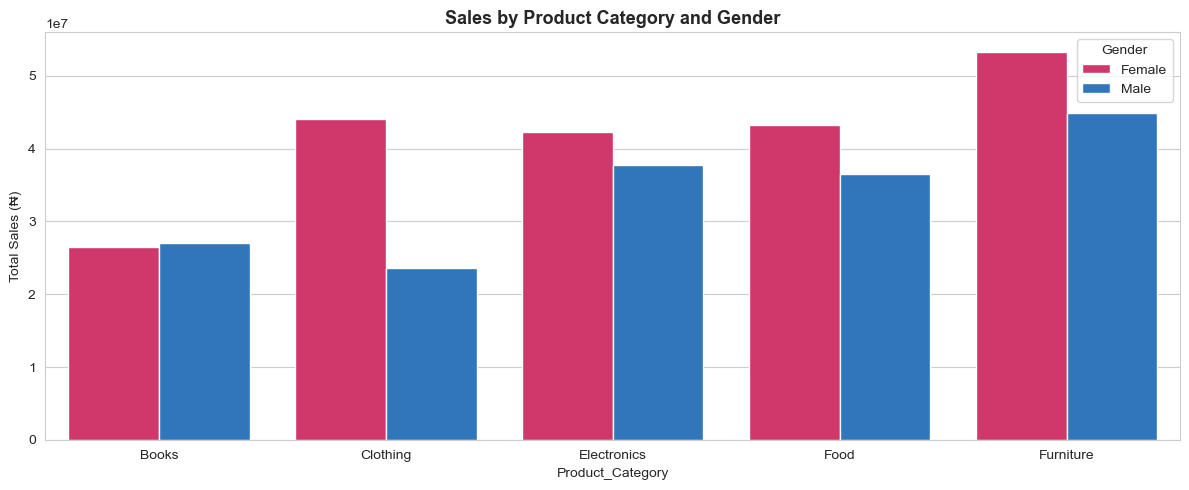

In [59]:
gender_cat = ( 
    df_balanced.groupby(['Gender','Product_Category'])['Total_Sales'] 
               .sum().reset_index() 
) 
  
fig, ax = plt.subplots(figsize=(12, 5)) 
sns.barplot(data=gender_cat, x='Product_Category', y='Total_Sales', 
            hue='Gender', 
            palette={'Female':'#E91E63','Male':'#1976D2'}, ax=ax) 
ax.set_title('Sales by Product Category and Gender', fontsize=13, 
fontweight='bold') 
ax.set_ylabel('Total Sales (₦)') 
ax.legend(title='Gender') 
plt.tight_layout() 
plt.show() 



In [61]:
# Monthly trend 
monthly_trend = ( 
    df_balanced.groupby(['Year','Month'])[['Total_Sales','Profit']] 
               .sum().reset_index().sort_values(['Year','Month']) 
) 
monthly_trend['Period'] = (monthly_trend['Year'].astype(str) + '-' 
                           + monthly_trend['Month'].astype(str).str.zfill(2)) 
  
# Category summary 
cat_summary = df_balanced.groupby('Product_Category').agg( 
    Total_Sales=('Total_Sales','sum'), 
    Profit=('Profit','sum'), 
    Orders=('Order_ID','count') 
).reset_index() 
  
# Region summary 
region_summary = df_balanced.groupby('Region').agg( 
    Total_Sales=('Total_Sales','sum'), 
    Profit=('Profit','sum') 
).reset_index() 
  
# Sales Rep summary 
rep_summary = df_balanced.groupby('Sales_Rep').agg( 
    Total_Sales=('Total_Sales','sum'), 
    Profit=('Profit','sum'), 
    Orders=('Order_ID','count') 
).reset_index() 
  
# Payment method 
pay_summary = df_balanced['Payment_Method'].value_counts().reset_index() 
pay_summary.columns = ['Payment_Method', 'Count'] 
  
print('Summary tables ready!') 

Summary tables ready!


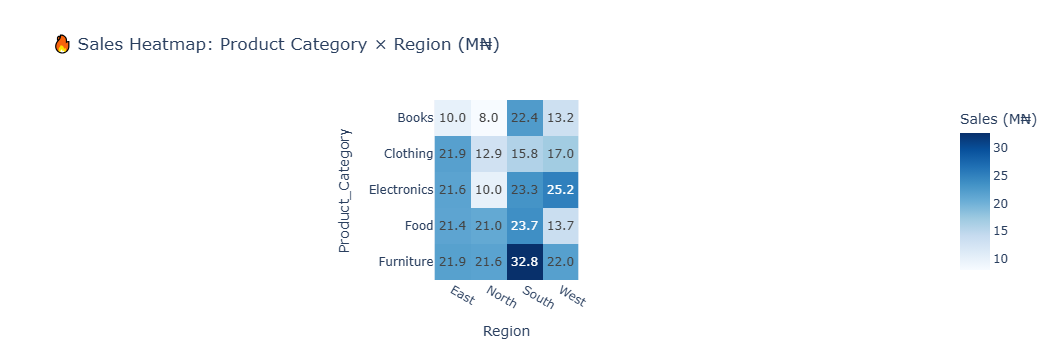

In [89]:
pivot = df_balanced.pivot_table( 
    values='Total_Sales', index='Product_Category', 
    columns='Region', aggfunc='sum' 
) / 1e6 
  
fig = px.imshow( 
    pivot, text_auto='.1f', 
    color_continuous_scale='Blues', 
    title='🔥 Sales Heatmap: Product Category × Region (M₦)', 
    labels={'color': 'Sales (M₦)'} 
) 
fig.update_layout(height=400) 